# Capstone 2: EmporiUm Sales Analysis

## Author: Naomi Tewolde 

## Sales Territory: 
### Region: Northeast
### States: Maine & Massachusetts

## Project Overview

In [1]:
# As part of this project, I conducted a business analysis for EmporiUm to better 
# understand sales performance across my assigned territories, the Northeast region
# (Maine and Massachusetts). My goal was to provide clear, data-driven insights that 
# can support your marketing decisions and help identify opportunities to improve sales
# performance. Using Python, Jupyter Notebook, and a structured analysis, I worked through
# the full process of cleaning, analyzing, and visualizing the data to highlight meaningful 
# patterns and comparisons between the territories.

In [2]:
# Importing essential libraries for data analysis and visualization

import numpy as np        # for fast numerical computations
import pandas as pd      # for organizing and analyzing data in tables
import matplotlib.pyplot as plt  # for creating charts and visual insights

## Loading CSV Files: 
##### Store Sales, Store Detail, Product Categories, Customer List, & Products

#### Store detail CSV file:

In [3]:
store_detail = pd.read_csv("StoreDetail.csv") # Importing/loading data

store_detail.info() # confirms the column names, number of non-null records, and dtype for each column 

store_detail.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [4]:
store_detail.tail() # Previewing DataFrame of last 5

,Store Location,State,Store ID,Territory Manager,Region,Region Director
106,Dallas,Texas,907,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
107,Denton,Texas,908,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
108,Desoto,Texas,909,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
109,Fort Worth,Texas,910,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
110,Georgetown,Texas,911,"Jeff ""Howdy"" Richards",South,Andy Gisselquist


#### Store sales CSV file:

In [5]:
store_sales = pd.read_csv("StoreSales.csv") # Importing/loading data

store_sales.info() # confirms the column names, number of non-null records, and dtype for each column

store_sales.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [6]:
store_sales.tail() # Previewing DataFrame of last 5

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
335124,12/31/2025,909,NaN,105353-A,20.36
335125,12/31/2025,909,332.0,105364-S,17.70
335126,12/31/2025,910,NaN,105672-B,26.52
335127,12/31/2025,910,NaN,105653-M,11.00
335128,12/31/2025,910,NaN,105300-IT,77.81


#### Products CSV file:

In [7]:
products = pd.read_csv("Products.csv") # Importing/loading data

products.info() # confirms the column names, number of non-null records, and dtype for each column

products.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [8]:
products.tail() # Previewing DataFrame of last 5

,Prod Num,Product,CategoryID,SubcategoryID
664,105912-T,Networking Fundamentals,100,100-tec
665,105913-T,Introduction to Databases,100,100-tec
666,105914-IT,SanDisk Extreme Portable SSD (1TB),120,120-ext
667,105915-M,LTCA Year Up Spiral Notebook (Black),130,130-off
668,105916-M,LTCA Year Up Sunglasses (Black),130,130-acc


#### Customer list CSV file: 

In [9]:
customer_list = pd.read_csv("customer_list.csv") # Importing/loading data

customer_list.info() # confirms the column names, number of non-null records, and dtype for each column

customer_list.head() # Previewing DataFrame of top 5 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    object
dtypes: object(1)
memory usage: 4.2+ KB


,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


In [10]:
customer_list.tail() # Previewing DataFrame of last 5 

,cust_id|date|time|name|email|phone|sms-opt-out
516,517|2024-02-15|11:30:30|Perry the Platypus|age...
517,518|2024-05-01|15:55:45|Baljeet|baljeet@danvil...
518,519|2023-03-05|09:20:00|Buford|buford@danville...
519,520|2023-05-18|13:45:15|Vanessa D.|vanessa@dan...
520,521|2023-08-01|18:10:30|Linda Flynn-Fletcher|l...


#### Product Categories CSV file:

In [11]:
productcategories = pd.read_csv("productcategories.csv") # Importing/loading data

productcategories.info() # confirms the column names, number of non-null records, and dtype for each column

productcategories.head() # Previewing DataFrame of top 5 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [12]:
productcategories.tail() # Previewing DataFrame of last 5 

,CategoryID,Category,SubcategoryID,Subcategory
47,110,Stationery and Supplies,110-pen,Pencils and Erasers
48,110,Stationery and Supplies,110-pap,Paper Products
49,125,Books (General),125-ref,Reference Materials
50,115,Art Supplies,115-pal,Palettes and Mixing Tools
51,115,Art Supplies,115-eas,Easels and Storage


## Core Marketing Analysis: 

##### Territory managers and assigned store locations

In [13]:
# Filtering stores in Maine and Massachusetts with manager and location info

territory_stores = store_detail[(store_detail['State'] == 'Maine')| 
                                 (store_detail['State'] == 'Massachusetts')] 
                                 
# displaying columns and rows in this order
territory_stores[['Store ID', 'Store Location', 'Territory Manager', 'State']]

,Store ID,Store Location,Territory Manager,State
37,818,Bangor,Erbayne Middleton,Maine
38,819,Bar Harbor,Erbayne Middleton,Maine
39,820,Kennebunkport,Erbayne Middleton,Maine
40,821,Lewiston,Erbayne Middleton,Maine
41,822,Orono,Erbayne Middleton,Maine
42,823,South Portland,Erbayne Middleton,Maine
52,730,Boston,Bo Heap,Massachusetts
53,801,Attleboro,Bo Heap,Massachusetts
54,802,Falmouth,Bo Heap,Massachusetts
55,803,Framingham,Bo Heap,Massachusetts


## Monthly Total Revenue for In-Store Sales

In [14]:
# This code calculates the monthly total in-store revenue for Maine and Massachusetts 
# by merging sales data with store location data from the matching column "store Id", 
# filtering for the selected states, and grouping by state and month.

In [15]:
# converting "Transaction Date" column to datetime
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# creating Month column
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

# merge in State info from store_detail
sales_with_state = store_sales.merge(
    store_detail[['Store ID', 'State']],
    on='Store ID'
)

# filter for Maine and Massachusetts
territory_sales = sales_with_state[
    (sales_with_state['State'] == 'Maine') |
    (sales_with_state['State'] == 'Massachusetts')
]

# group by State, Month, and calculate total revenue
monthly_revenue = territory_sales.groupby(
    ['State', 'Month']
)['Sale Amount'].sum().reset_index()

# display results
monthly_revenue

,State,Month,Sale Amount
0,Maine,2022-01,15700.31
1,Maine,2022-02,21008.29
2,Maine,2022-03,23173.23
3,Maine,2022-04,20169.19
4,Maine,2022-05,22631.11
...,...,...,...
91,Massachusetts,2025-08,174867.46
92,Massachusetts,2025-09,168503.25
93,Massachusetts,2025-10,277382.19
94,Massachusetts,2025-11,196108.93


### Line graph for Monthly Total Revenue for Maine and Massachusetts

##### This graph shows the monthly total in-store revenue for Maine and Massachusetts, allowing for comparison of sales trends over time between the two states.

In [16]:
# reshape DataFrame for plotting
pivot_table = monthly_revenue.pivot(
    index='Month',
    columns='State',
    values='Sale Amount'
)

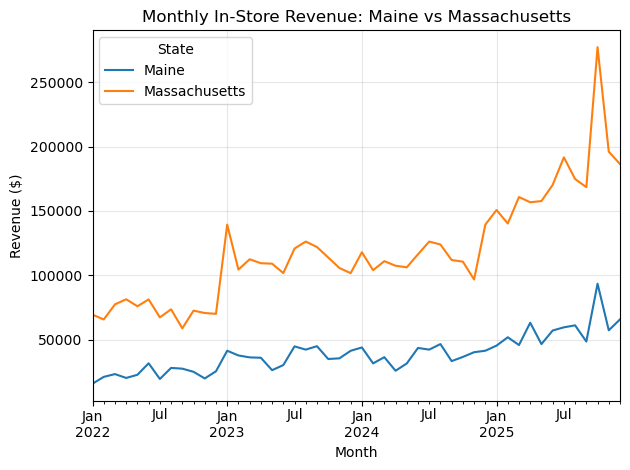

In [17]:
pivot_table.plot()  

plt.title("Monthly In-Store Revenue: Maine vs Massachusetts")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend(title="State")

plt.grid(alpha=0.3)  # adds light gridlines

plt.tight_layout()

plt.show()

#### Line Graph Analysis:
##### Massachusetts consistently generates significantly higher revenue than Maine. The gap between the two states
##### increases over time, indicating that Massachusetts is outperforming Maine by a growing margin.
##### However, the scale of revenue is much larger in Massachusetts, highlighting stronger market performance in that territory.
##### Maine shows a more stable and moderate revenue trend, with lower overall revenue totals.
##### In contrast, Massachusetts demonstrates higher variability and growth, with noticeable increases and larger revenue spikes across several months.
##### The graph also reveals fluctuations across months, which could be influenced by seasonal shopping trends, promotional periods, or High-value product sales.
##### Overall, the trend suggests that while both states are impacted by similar external factors, like for example the holiday season,
##### Massachusetts dominates in total revenue and shows stronger growth, whereas Maine maintains steady but comparatively lower sales.

## Ranking Store Performance

In [ ]:
# This code processes sales data by converting dates, merging in store location
# and state information, and filtering for Maine and Massachusetts. It then calculates 
# total revenue for each store, ranks the stores within each state based on performance,
# and organizes the results from highest to lowest revenue.

In [18]:
# converting Transaction Date column to datetime
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# merge in State + Store Location
sales_with_info = store_sales.merge(
    store_detail[['Store ID', 'State', 'Store Location']],
    on='Store ID'
)

# filter for Maine and Massachusetts
territory_sales = sales_with_info[
    (sales_with_info['State'] == 'Maine') |
    (sales_with_info['State'] == 'Massachusetts')
]

# group by State, Store ID, and Location
store_performance = territory_sales.groupby(
    ['State', 'Store ID', 'Store Location']
)['Sale Amount'].sum().reset_index()

# rank stores within each state (1 = highest revenue)
store_performance['Rank'] = store_performance.groupby('State')['Sale Amount'].rank(
    ascending=False, method='dense'
)

# sort results
store_performance = store_performance.sort_values(['State', 'Rank'])

### Maine Store Ranking

In [20]:
maine_stores = store_performance[store_performance['State'] == 'Maine']
maine_stores

,State,Store ID,Store Location,Sale Amount,Rank
5,Maine,823,South Portland,332611.76,1.0
4,Maine,822,Orono,330505.47,2.0
2,Maine,820,Kennebunkport,321998.55,3.0
3,Maine,821,Lewiston,303761.91,4.0
0,Maine,818,Bangor,300919.98,5.0
1,Maine,819,Bar Harbor,287452.08,6.0


#### Analysis:
##### The spread between the highest and lowest top-ranked store is not extreme, 
##### indicating that revenue is evenly distributed across major Maine locations rather 
##### than being dominated by a single store. This pattern suggests consistent customer
##### demand and stable performance across the state.

### Massachusetts Store Ranking

In [21]:
mass_stores = store_performance[store_performance['State'] == 'Massachusetts']
mass_stores

,State,Store ID,Store Location,Sale Amount,Rank
23,Massachusetts,817,Worcester,602183.44,1.0
13,Massachusetts,807,Leominster,338009.10,2.0
16,Massachusetts,810,Nantucket,335547.81,3.0
20,Massachusetts,814,Provincetown,328860.51,4.0
18,Massachusetts,812,Northampton,322039.24,5.0
12,Massachusetts,806,Holyoke,320516.53,6.0
22,Massachusetts,816,Somerville,312873.59,7.0
10,Massachusetts,804,Haverhill,305762.60,8.0
15,Massachusetts,809,Lynn,302049.65,9.0
19,Massachusetts,813,Pittsfield,301281.50,10.0


#### Analysis:
##### The analysis shows that Massachusetts substantially outperforms Maine in 
##### store-level revenue, driven largely by high-performing locations such as Worcester.
##### While Maine demonstrates consistent and balanced store performance, Massachusetts
##### benefits from both higher overall revenue and the presence of standout stores, 
##### indicating a stronger and more dynamic market.

## Top 5 Performing Stores for Maine and Massachusetts
### Bar Graph 

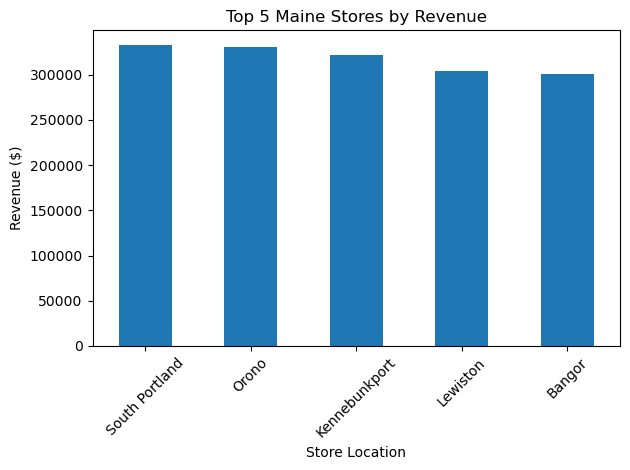

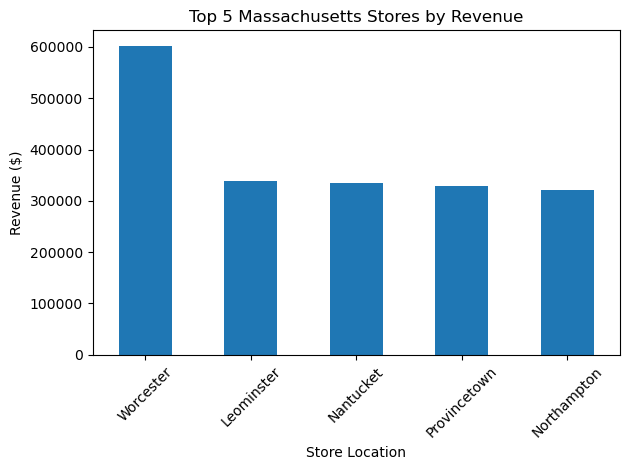

In [25]:
# top 5 Maine stores
maine_top5 = maine_stores[maine_stores['Rank'] <= 5]

maine_top5.sort_values('Rank').plot(
    kind='bar',
    x='Store Location',
    y='Sale Amount',
    title='Top 5 Maine Stores by Revenue',
    legend=False
)

plt.ylabel("Revenue ($)")
plt.xticks(rotation=45) # For readability 
plt.tight_layout()
plt.show()


# top 5 Massachusetts
mass_top5 = mass_stores[mass_stores['Rank'] <= 5]

mass_top5.sort_values('Rank').plot(
    kind='bar',
    x='Store Location',
    y='Sale Amount',
    title='Top 5 Massachusetts Stores by Revenue',
    legend=False
)

plt.ylabel("Revenue ($)")
plt.xticks(rotation=45) # For readability 
plt.tight_layout()
plt.show()


#### Bar Graph Analysis:
##### Massachusetts’ top stores significantly outperform those in Maine,
##### with much higher revenue and stronger overall market presence. Maine’s 
##### top stores, however, show more consistent and evenly distributed performance, 
##### indicating stable but moderate demand. In contrast, Massachusetts demonstrates
##### greater revenue variability and high-performing hotspots, suggesting stronger
##### customer traffic and larger market opportunities.